# 08 — SHAP Analysis

This notebook explains the exact final model saved by `07_machine_learning.ipynb`. It does not train or tune a model, create a split, select a threshold, or evaluate performance.

**Data flow:** saved model + saved preprocessor + metadata/split indices + feature-engineered data → global, dependence, and customer-level SHAP → CSV/JSON artifacts and figures.

SHAP describes contributions to model output; it does not establish causal effects. The source dataset has no `Customer_ID` column, so customer-level output uses the original dataset row index as the identifier.


## Section 01 — SHAP Configuration and Reproducibility

In [19]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from scipy import sparse
from scipy.special import expit
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = 'Churned'
TOP_N_FEATURES = 20
TOP_N_LOCAL_FEATURES = 10
SHAP_SAMPLE_SIZE = 2000
LOCAL_CUSTOMER_INDEX = None  # Set to an original dataset row index to explain a specific test customer.
CHURN_CLASS = 1

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks' or not (PROJECT_ROOT / 'data').exists():
    if (PROJECT_ROOT.parent / 'data').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'customer_churn_feature_engineered.csv'
MODELS_DIR = PROJECT_ROOT / 'models'
FINAL_MODEL_PATH = MODELS_DIR / 'final_model.joblib'
FINAL_MODEL_METADATA_PATH = MODELS_DIR / 'final_model_metadata.json'
PREPROCESSOR_PATH = MODELS_DIR / 'preprocessor.joblib'
PREPROCESSOR_METADATA_PATH = MODELS_DIR / 'preprocessor_metadata.json'
SPLIT_INDICES_PATH = MODELS_DIR / 'data_split_indices.json'
SHAP_OUTPUT_DIR = MODELS_DIR / 'shap'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'shap'

print(f'Target: {TARGET}')
print(f'Random state: {RANDOM_STATE}')
print('SHAP analysis: Enabled')
print(f'Project root: {PROJECT_ROOT}')


Target: Churned
Random state: 42
SHAP analysis: Enabled
Project root: D:\Desktop\Projects\customer-churn-analytics


## Section 02 — Load ML Artifacts


In [20]:
final_model = joblib.load(FINAL_MODEL_PATH)
preprocessor = joblib.load(PREPROCESSOR_PATH)
with FINAL_MODEL_METADATA_PATH.open('r', encoding='utf-8') as metadata_file:
    final_model_metadata = json.load(metadata_file)
with PREPROCESSOR_METADATA_PATH.open('r', encoding='utf-8') as metadata_file:
    preprocessor_metadata = json.load(metadata_file)
with SPLIT_INDICES_PATH.open('r', encoding='utf-8') as indices_file:
    split_indices = json.load(indices_file)

print(f"Final model loaded: {final_model_metadata['model_name']}")
print('Preprocessor loaded')
print('Model and preprocessor metadata loaded')
print('Split indices loaded')

Final model loaded: Tuned XGBoost
Preprocessor loaded
Model and preprocessor metadata loaded
Split indices loaded


## Section 03 — Load Dataset and Metadata

In [21]:
df = pd.read_csv(DATA_PATH)
approved_features = preprocessor_metadata['approved_features']
forbidden_features = preprocessor_metadata['forbidden_features']
assert TARGET in df.columns, f"Target column '{TARGET}' does not exist in the dataset."
assert approved_features, 'Preprocessor metadata has no approved_features.'
assert set(approved_features).issubset(df.columns), 'Approved feature columns are missing from the dataset.'
assert not set(forbidden_features).intersection(df.columns), 'Forbidden target-derived feature exists in the dataset.'
assert TARGET not in approved_features, 'Target leakage: target is listed as an approved feature.'
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Approved input features: {len(approved_features)}')

Dataset loaded: 50,000 rows × 33 columns
Approved input features: 32


## Section 04 — Reconstruct ML Data

In [22]:
assert df.index.is_unique, 'Dataset row indices must be unique to reconstruct the saved splits.'
assert final_model_metadata['target'] == TARGET == preprocessor_metadata['target']
assert final_model_metadata['random_state'] == RANDOM_STATE
assert preprocessor_metadata['random_state'] == RANDOM_STATE

X = df.loc[:, approved_features].copy()
y = df[TARGET].copy()
train_indices = split_indices['train_indices']
validation_indices = split_indices['validation_indices']
test_indices = split_indices['test_indices']

assert set(train_indices).isdisjoint(validation_indices)
assert set(train_indices).isdisjoint(test_indices)
assert set(validation_indices).isdisjoint(test_indices)
assert set(train_indices) | set(validation_indices) | set(test_indices) == set(df.index), 'Saved split indices do not cover this dataset exactly.'

X_train = X.loc[train_indices].copy()
y_train = y.loc[train_indices].copy()
X_valid = X.loc[validation_indices].copy()
y_valid = y.loc[validation_indices].copy()
X_test = X.loc[test_indices].copy()
y_test = y.loc[test_indices].copy()

# Reuse the fitted Notebook 06 preprocessor; transform only, never fit.
X_train_processed = preprocessor.transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)


## Section 05 — Validate Model and Feature Contract


In [23]:
def to_dense(matrix):
    if sparse.issparse(matrix):
        return matrix.toarray()
    return np.asarray(matrix)

def assert_no_nan(matrix, matrix_name):
    values = matrix.data if sparse.issparse(matrix) else np.asarray(matrix)
    assert np.isfinite(values).all(), f'{matrix_name} contains NaN or infinite values.'

processed_feature_names = final_model_metadata['processed_feature_names']
preprocessor_feature_names = preprocessor_metadata['processed_feature_names']
assert processed_feature_names == preprocessor_feature_names, 'Model and preprocessor feature names do not match.'
assert len(processed_feature_names) == final_model_metadata['processed_feature_count']
assert len(processed_feature_names) == preprocessor_metadata['processed_feature_count']
assert len(approved_features) == final_model_metadata['original_feature_count']
assert X_train_processed.shape[1] == len(processed_feature_names)
assert X_valid_processed.shape[1] == len(processed_feature_names)
assert X_test_processed.shape[1] == len(processed_feature_names)
assert final_model.n_features_in_ == len(processed_feature_names), 'Final model feature count does not match transformed data.'
assert CHURN_CLASS in final_model.classes_, f'Churn class {CHURN_CLASS} is not present in the final model.'
assert_no_nan(X_train_processed, 'Transformed training data')
assert_no_nan(X_valid_processed, 'Transformed validation data')
assert_no_nan(X_test_processed, 'Transformed test data')

class_index = list(final_model.classes_).index(CHURN_CLASS)
processed_feature_names = list(processed_feature_names)
X_valid_processed_df = pd.DataFrame(
    to_dense(X_valid_processed), columns=processed_feature_names, index=X_valid.index
)
X_train_processed_df = pd.DataFrame(
    to_dense(X_train_processed), columns=processed_feature_names, index=X_train.index
)
X_test_processed_df = pd.DataFrame(
    to_dense(X_test_processed), columns=processed_feature_names, index=X_test.index
)
print(f'Train / validation / test rows: {len(X_train):,} / {len(X_valid):,} / {len(X_test):,}')
print(f'Processed feature count: {len(processed_feature_names)} — contract matched')
print('No forbidden features, NaN, or infinite transformed values detected')

Train / validation / test rows: 35,000 / 7,500 / 7,500
Processed feature count: 54 — contract matched
No forbidden features, NaN, or infinite transformed values detected


## Section 06 — Prepare SHAP Dataset

In [24]:
# Explain a reproducible sample from the saved validation split; do not use it for fitting,
# tuning, threshold selection, or model-performance evaluation.
shap_sample_count = min(SHAP_SAMPLE_SIZE, len(X_valid_processed_df))
X_shap = X_valid_processed_df.sample(n=shap_sample_count, random_state=RANDOM_STATE).sort_index()
assert len(X_shap) > 0
assert X_shap.columns.tolist() == processed_feature_names
print(f'SHAP analysis dataset: validation split sample ({len(X_shap):,} of {len(X_valid):,} rows)')
print(f'Sampling is reproducible with random_state={RANDOM_STATE}; this sample is used only for explanations.')


SHAP analysis dataset: validation split sample (2,000 of 7,500 rows)
Sampling is reproducible with random_state=42; this sample is used only for explanations.


## Section 07 — Create SHAP Explainer


In [25]:
background = X_train_processed_df.sample(
    n=min(100, len(X_train_processed_df)), random_state=RANDOM_STATE
)
TREE_MODEL_TYPES = (
    XGBClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    DecisionTreeClassifier,
    ExtraTreeClassifier,
)
if isinstance(final_model, TREE_MODEL_TYPES):
    explainer = shap.TreeExplainer(final_model)
    if isinstance(final_model, XGBClassifier):
        shap_output_scale = 'XGBoost binary raw margin (log-odds; not probability points)'
    else:
        shap_output_scale = 'tree explainer model output (raw scale)'
elif isinstance(final_model, LogisticRegression):
    explainer = shap.LinearExplainer(final_model, background)
    shap_output_scale = 'linear explainer model output (raw scale)'
else:
    explainer = shap.Explainer(
        final_model.predict_proba, background, algorithm='permutation'
    )
    shap_output_scale = 'class probability from predict_proba'
print(f'SHAP explainer: {type(explainer).__name__}')
print(f'Explained output: {shap_output_scale}; churn class={CHURN_CLASS}')


SHAP explainer: TreeExplainer
Explained output: XGBoost binary raw margin (log-odds; not probability points); churn class=1


## Section 08 — Global SHAP Analysis


In [26]:
shap_result = explainer(X_shap)
shap_values_all_outputs = np.asarray(shap_result.values)
if shap_values_all_outputs.ndim == 3:
    assert class_index < shap_values_all_outputs.shape[2], 'SHAP output does not contain the churn class.'
    shap_values = shap_values_all_outputs[:, :, class_index]
elif shap_values_all_outputs.ndim == 2:
    shap_values = shap_values_all_outputs
else:
    raise ValueError(f'Unsupported SHAP value shape: {shap_values_all_outputs.shape}')

base_values_all_outputs = np.asarray(shap_result.base_values)
if base_values_all_outputs.ndim == 2:
    base_values = base_values_all_outputs[:, class_index]
elif base_values_all_outputs.ndim == 1:
    base_values = base_values_all_outputs
else:
    raise ValueError(f'Unsupported SHAP base value shape: {base_values_all_outputs.shape}')
assert shap_values.shape == X_shap.shape, 'SHAP values do not match the sample and processed feature dimensions.'
assert np.isfinite(shap_values).all(), 'SHAP values contain NaN or infinite values.'
assert np.isfinite(base_values).all(), 'SHAP base values contain NaN or infinite values.'

shap_consistency_validation = 'not applicable for this explainer/model combination'
if isinstance(final_model, XGBClassifier):
    expected_raw_output = np.asarray(
        final_model.predict(X_shap, output_margin=True)
    ).reshape(-1)
    reconstructed_raw_output = base_values + shap_values.sum(axis=1)
    assert np.allclose(
        reconstructed_raw_output, expected_raw_output, rtol=1e-5, atol=1e-4
    ), 'SHAP additivity check failed against the XGBoost raw margins.'
    predicted_probabilities = final_model.predict_proba(X_shap)[:, class_index]
    assert np.allclose(
        expit(expected_raw_output), predicted_probabilities, rtol=1e-5, atol=1e-6
    ), 'XGBoost raw margins do not reproduce the churn probabilities.'
    shap_consistency_validation = 'passed: SHAP additivity to raw margin and logistic-link probability consistency'

shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=base_values,
    data=X_shap.to_numpy(),
    feature_names=processed_feature_names,
)
print(f'Global SHAP values calculated: {shap_values.shape[0]:,} rows × {shap_values.shape[1]} features')
print(f'SHAP/model consistency: {shap_consistency_validation}')



Global SHAP values calculated: 2,000 rows × 54 features
SHAP/model consistency: passed: SHAP additivity to raw margin and logistic-link probability consistency


## Section 09 — SHAP Feature Importance


In [27]:
shap_global_summary = pd.DataFrame({
    'Feature': processed_feature_names,
    'Mean_SHAP': np.mean(shap_values, axis=0),
    'Mean_Abs_SHAP': np.mean(np.abs(shap_values), axis=0),
    'Min_SHAP': np.min(shap_values, axis=0),
    'Max_SHAP': np.max(shap_values, axis=0),
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)
shap_global_summary.insert(0, 'Rank', np.arange(1, len(shap_global_summary) + 1))
shap_feature_importance = shap_global_summary[['Rank', 'Feature', 'Mean_Abs_SHAP']].copy()
assert shap_global_summary['Mean_Abs_SHAP'].notna().all()
print(shap_feature_importance.head(TOP_N_FEATURES).to_string(index=False, float_format='{:.6f}'.format))

 Rank                            Feature  Mean_Abs_SHAP
    1                num__Lifetime_Value       0.835753
    2        num__Customer_Service_Calls       0.806775
    3         num__Cart_Abandonment_Rate       0.440911
    4                           num__Age       0.416268
    5      num__Cart_Recency_Interaction       0.327927
    6              num__Engagement_Score       0.325700
    7           num__Discount_Usage_Rate       0.319177
    8               num__Email_Open_Rate       0.229840
    9                  num__Returns_Rate       0.203234
   10               num__Total_Purchases       0.149556
   11                num__Wishlist_Items       0.105603
   12 num__Social_Media_Engagement_Score       0.103865
   13       num__Product_Reviews_Written       0.085227
   14           num__Average_Order_Value       0.069109
   15      num__Estimated_Purchase_Value       0.064615
   16          num__Session_Duration_Avg       0.063698
   17   cat__Cart_Abandonment_Group_High       0

## Section 10 — SHAP Summary Visualization


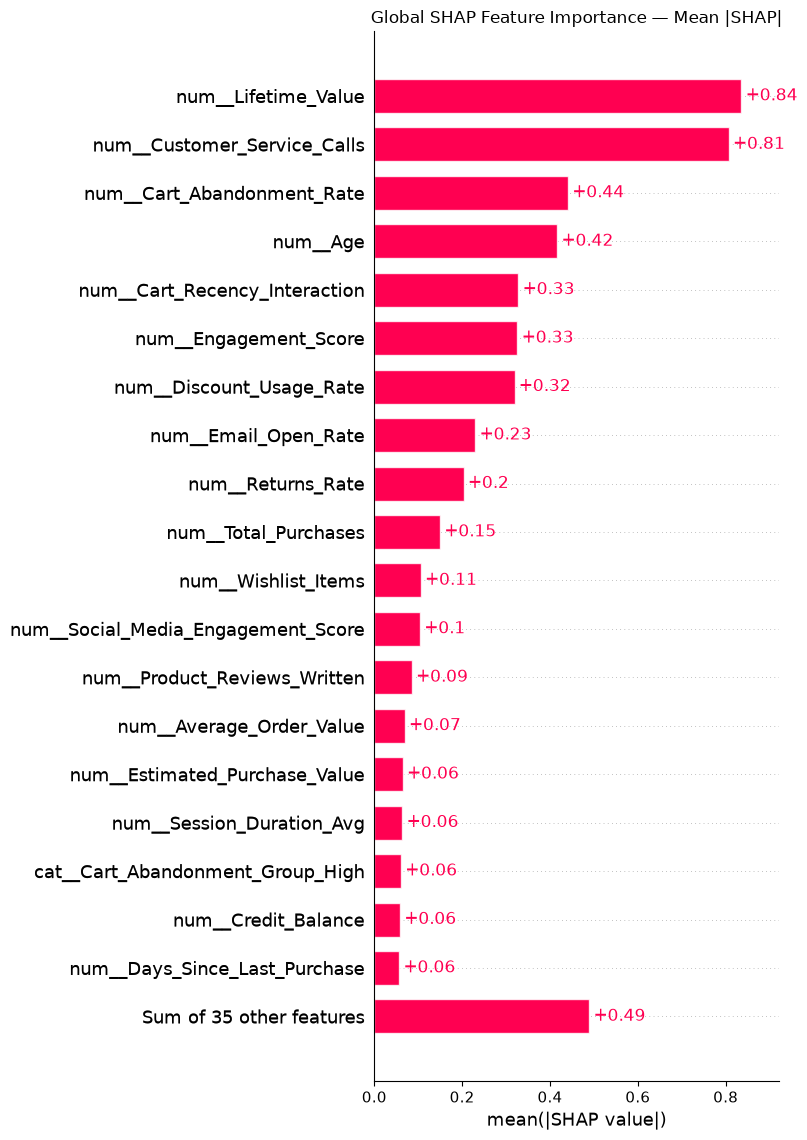

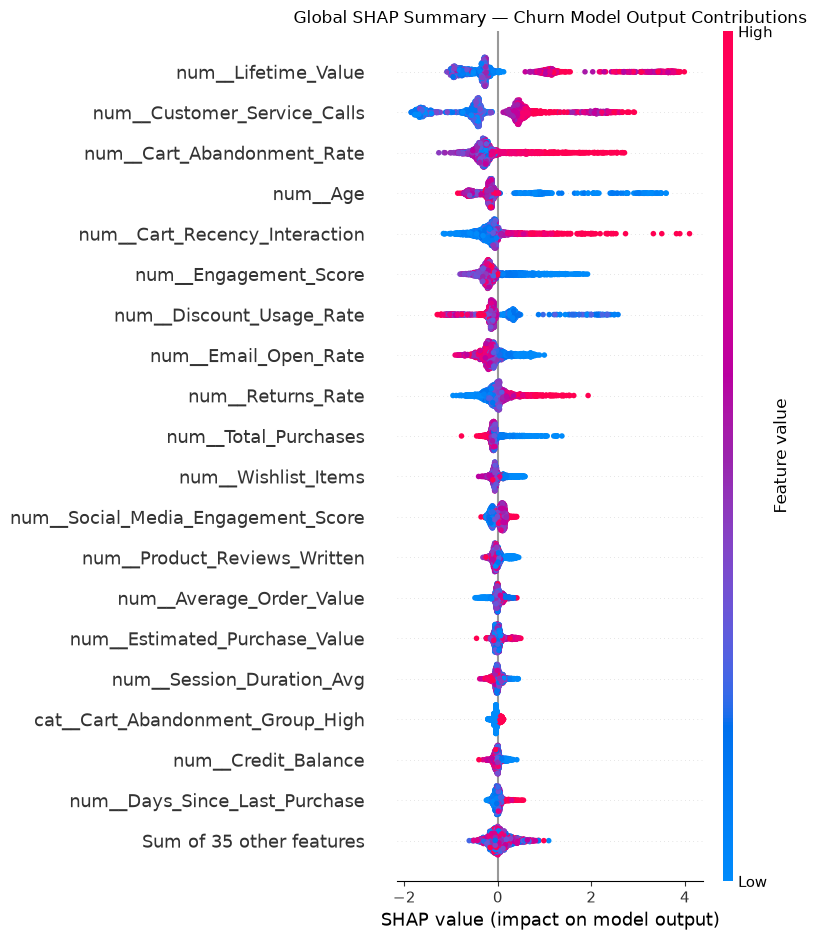

In [28]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
max_display = min(TOP_N_FEATURES, len(processed_feature_names))

shap.plots.bar(shap_explanation, max_display=max_display, show=False)
plt.title('Global SHAP Feature Importance — Mean |SHAP|')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

shap.plots.beeswarm(shap_explanation, max_display=max_display, show=False)
plt.title('Global SHAP Summary — Churn Model Output Contributions')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


## Section 11 — SHAP Dependence Analysis


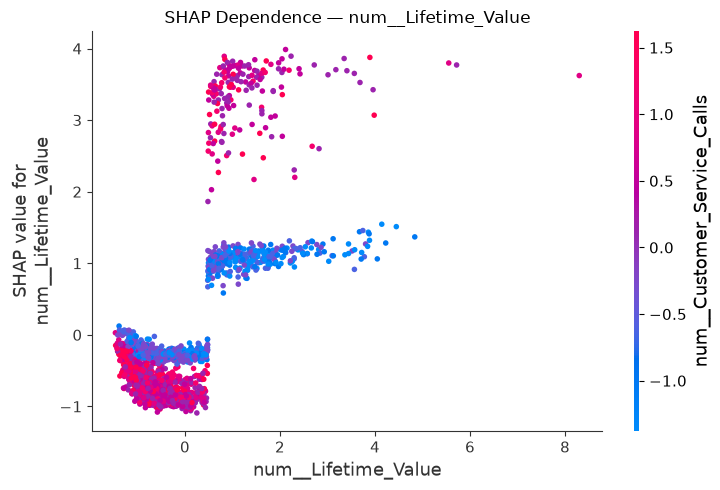

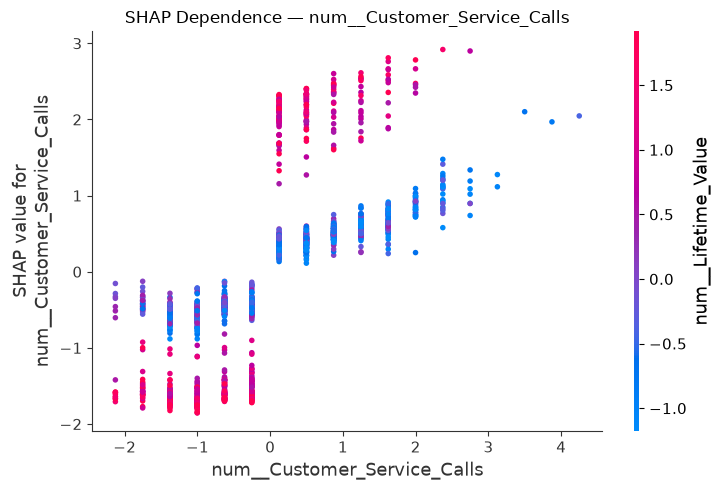

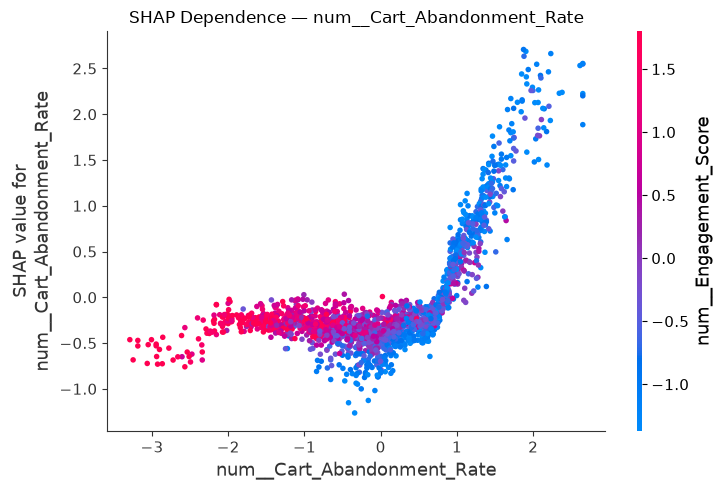

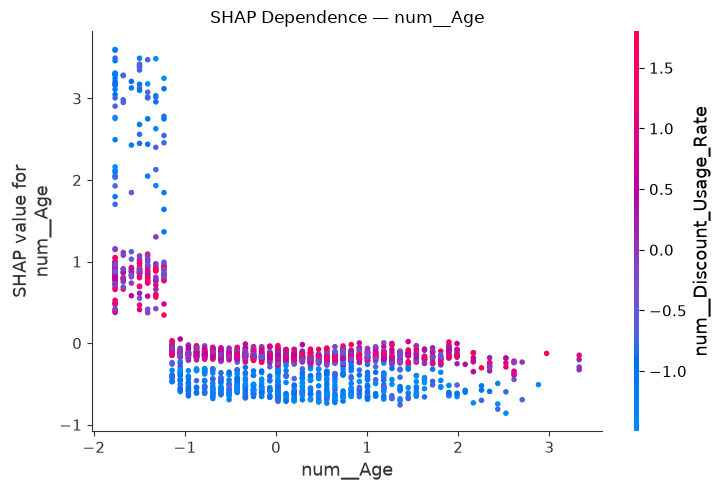

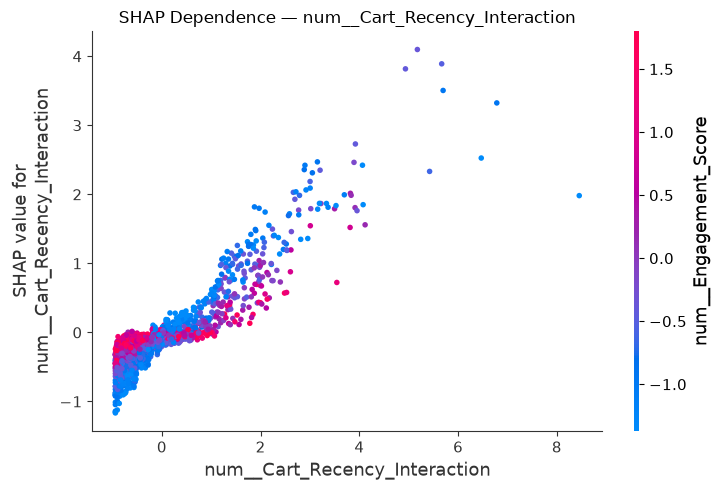

Global bar, beeswarm, and 5 dependence plots saved to D:\Desktop\Projects\customer-churn-analytics\reports\figures\shap


In [34]:
for feature_name in shap_global_summary.head(min(5, len(shap_global_summary)))['Feature']:
    shap.dependence_plot(
        feature_name,
        shap_values,
        X_shap,
        feature_names=processed_feature_names,
        interaction_index='auto',
        show=False,
    )
    plt.title(f'SHAP Dependence — {feature_name}')
    plt.tight_layout()
    safe_feature_name = ''.join(
        character if character.isalnum() or character in ('-', '_') else '_'
        for character in feature_name
    )
    plt.savefig(FIGURES_DIR / f'shap_dependence_{safe_feature_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
print(f'Global bar, beeswarm, and {min(5, len(shap_global_summary))} dependence plots saved to {FIGURES_DIR}')


## Section 12 — Local Customer Explanation


In [33]:
if LOCAL_CUSTOMER_INDEX is None:
    customer_index = test_indices[0]
else:
    customer_index = LOCAL_CUSTOMER_INDEX
assert customer_index in X_test_processed_df.index, 'Choose a customer row index from the saved test split.'

X_customer = X_test_processed_df.loc[[customer_index]]
customer_probability = float(final_model.predict_proba(X_customer)[0, class_index])
threshold = float(final_model_metadata['threshold'])
customer_prediction = 'Churn' if customer_probability >= threshold else 'No Churn'
local_result = explainer(X_customer)
local_values_all_outputs = np.asarray(local_result.values)
if local_values_all_outputs.ndim == 3:
    local_shap_values = local_values_all_outputs[0, :, class_index]
elif local_values_all_outputs.ndim == 2:
    local_shap_values = local_values_all_outputs[0]
else:
    raise ValueError(f'Unsupported local SHAP value shape: {local_values_all_outputs.shape}')
assert local_shap_values.shape == (len(processed_feature_names),)
assert np.isfinite(local_shap_values).all(), 'Local SHAP values contain NaN or infinite values.'

local_base_values_all_outputs = np.asarray(local_result.base_values)
if local_base_values_all_outputs.ndim == 2:
    local_base_value = float(local_base_values_all_outputs[0, class_index])
elif local_base_values_all_outputs.ndim == 1:
    local_base_value = float(local_base_values_all_outputs[0])
elif local_base_values_all_outputs.ndim == 0:
    local_base_value = float(local_base_values_all_outputs)
else:
    raise ValueError(f'Unsupported local SHAP base value shape: {local_base_values_all_outputs.shape}')

if isinstance(final_model, XGBClassifier):
    local_raw_output = float(
        np.asarray(final_model.predict(X_customer, output_margin=True)).reshape(-1)[0]
    )
    reconstructed_local_output = local_base_value + float(local_shap_values.sum())
    assert np.isclose(
        reconstructed_local_output, local_raw_output, rtol=1e-5, atol=1e-4
    ), 'Local SHAP additivity check failed against the XGBoost raw margin.'
    assert np.isclose(
        expit(local_raw_output), customer_probability, rtol=1e-5, atol=1e-6
    ), 'Local XGBoost raw margin does not reproduce the churn probability.'

has_customer_id = 'Customer_ID' in df.columns
customer_identifier_column = 'Customer_ID' if has_customer_id else 'Customer_Row_Index'
customer_identifier = (
    df.loc[customer_index, 'Customer_ID'] if has_customer_id else int(customer_index)
)
shap_local_explanations = pd.DataFrame({
    customer_identifier_column: customer_identifier,
    'Feature': processed_feature_names,
    'Feature_Value': X_customer.iloc[0].to_numpy(),
    'SHAP_Value': local_shap_values,
})
shap_local_explanations['Contribution_Direction'] = np.select(
    [shap_local_explanations['SHAP_Value'] > 0, shap_local_explanations['SHAP_Value'] < 0],
    ['Increases churn model output', 'Decreases churn model output'],
    default='No directional contribution',
)
shap_local_explanations['Rank'] = (
    shap_local_explanations['SHAP_Value'].abs().rank(method='first', ascending=False).astype(int)
)
shap_local_explanations = shap_local_explanations.sort_values('Rank').reset_index(drop=True)

print(f'{customer_identifier_column}: {customer_identifier}')
print(f'Prediction: {customer_prediction}')
print(f'Churn probability: {customer_probability:.4f}')
print(f'Notebook 07 threshold (unchanged): {threshold:.4f}')
print(f'SHAP contribution scale: {shap_output_scale}')
print('\nTop factors increasing churn model output:')
print(
    shap_local_explanations[shap_local_explanations['SHAP_Value'] > 0]
    .head(TOP_N_LOCAL_FEATURES)[['Feature', 'Feature_Value', 'SHAP_Value']]
    .to_string(index=False, float_format='{:.6f}'.format)
)
print('\nTop factors decreasing churn model output:')
print(
    shap_local_explanations[shap_local_explanations['SHAP_Value'] < 0]
    .sort_values('SHAP_Value')
    .head(TOP_N_LOCAL_FEATURES)[['Feature', 'Feature_Value', 'SHAP_Value']]
    .to_string(index=False, float_format='{:.6f}'.format)
)


Customer_Row_Index: 21742
Prediction: No Churn
Churn probability: 0.0247
Notebook 07 threshold (unchanged): 0.4000
SHAP contribution scale: XGBoost binary raw margin (log-odds; not probability points)

Top factors increasing churn model output:
                           Feature  Feature_Value  SHAP_Value
               num__Lifetime_Value       0.981488    1.200479
num__Social_Media_Engagement_Score       0.985172    0.064242
           num__Purchase_Frequency       0.223918    0.042775
              num__Login_Frequency       0.687532    0.025885
               cat__Country_France       0.000000    0.012998
            cat__Signup_Quarter_Q3       1.000000    0.005600
                  cat__Gender_Male       1.000000    0.003757
  cat__Service_Call_Group_Moderate       0.000000    0.001207

Top factors decreasing churn model output:
                                Feature  Feature_Value  SHAP_Value
            num__Customer_Service_Calls      -1.378425   -1.756575
             num__C

## Section 13 — Business Interpretation


In [31]:
print('Business interpretation — model associations, not causal conclusions')
print('Global features most influential in the model output for the analyzed validation sample:')
for row in shap_global_summary.head(5).itertuples(index=False):
    print(
        f'- {row.Feature}: mean |SHAP|={row.Mean_Abs_SHAP:.6f}; '
        f'mean signed SHAP={row.Mean_SHAP:.6f}. '
        'This is a contribution to the model output, not a probability-point change.'
    )
if isinstance(final_model, XGBClassifier):
    print(
        'For this binary XGBoost model, SHAP contributions are on the raw-margin '
        '(log-odds) scale. Positive values move the score toward the churn class; '
        'they are not direct changes in churn probability. The probability is reported '
        'separately from predict_proba().'
    )
else:
    print(
        f'SHAP contribution scale: {shap_output_scale}. Positive values move the '
        'explained output toward the churn class; they are not necessarily probability '
        'changes. The probability is reported separately from predict_proba().'
    )
print('SHAP describes how the model uses features; it does not prove that any feature causes churn.')


Business interpretation — model associations, not causal conclusions
Global features most influential in the model output for the analyzed validation sample:
- num__Lifetime_Value: mean |SHAP|=0.835753; mean signed SHAP=0.080729. This is a contribution to the model output, not a probability-point change.
- num__Customer_Service_Calls: mean |SHAP|=0.806775; mean signed SHAP=-0.028221. This is a contribution to the model output, not a probability-point change.
- num__Cart_Abandonment_Rate: mean |SHAP|=0.440911; mean signed SHAP=-0.084513. This is a contribution to the model output, not a probability-point change.
- num__Age: mean |SHAP|=0.416268; mean signed SHAP=-0.054078. This is a contribution to the model output, not a probability-point change.
- num__Cart_Recency_Interaction: mean |SHAP|=0.327927; mean signed SHAP=-0.064971. This is a contribution to the model output, not a probability-point change.
For this binary XGBoost model, SHAP contributions are on the raw-margin (log-odds) s

## Section 14 — Save SHAP Artifacts and Validate


In [32]:
SHAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
feature_importance_path = SHAP_OUTPUT_DIR / 'shap_feature_importance.csv'
global_summary_path = SHAP_OUTPUT_DIR / 'shap_global_summary.csv'
local_explanations_path = SHAP_OUTPUT_DIR / 'shap_local_explanations.csv'
shap_metadata_path = SHAP_OUTPUT_DIR / 'shap_metadata.json'

shap_feature_importance.to_csv(feature_importance_path, index=False)
shap_global_summary[['Feature', 'Mean_SHAP', 'Mean_Abs_SHAP', 'Min_SHAP', 'Max_SHAP']].to_csv(
    global_summary_path, index=False
)
local_output_columns = [
    customer_identifier_column,
    'Feature',
    'Feature_Value',
    'SHAP_Value',
    'Contribution_Direction',
    'Rank',
]
shap_local_explanations[local_output_columns].to_csv(local_explanations_path, index=False)

shap_metadata = {
    'model_name': final_model_metadata['model_name'],
    'target': TARGET,
    'random_state': RANDOM_STATE,
    'analysis_dataset': 'validation split sample',
    'n_samples': int(len(X_shap)),
    'processed_feature_count': int(len(processed_feature_names)),
    'top_n_features': int(TOP_N_FEATURES),
    'shap_output_scale': shap_output_scale,
    'shap_consistency_validation': shap_consistency_validation,
    'churn_class': CHURN_CLASS,
    'threshold': threshold,
    'local_customer_identifier_column': customer_identifier_column,
    'local_customer_identifier': customer_identifier,
    'local_customer_dataset_index': int(customer_index),
    'local_customer_prediction': customer_prediction,
    'local_customer_churn_probability': customer_probability,
    'local_customer_explanation_dataset': 'saved test split',
}
with shap_metadata_path.open('w', encoding='utf-8') as metadata_file:
    json.dump(shap_metadata, metadata_file, indent=2, ensure_ascii=False)

for artifact_path in (
    feature_importance_path,
    global_summary_path,
    local_explanations_path,
    shap_metadata_path,
):
    assert artifact_path.exists(), f'Expected SHAP artifact was not saved: {artifact_path}'
assert len(shap_feature_importance) == len(processed_feature_names)
assert len(shap_global_summary) == len(processed_feature_names)
assert len(shap_local_explanations) == len(processed_feature_names)
assert np.isfinite(shap_values).all()
assert np.isfinite(shap_global_summary[['Mean_SHAP', 'Mean_Abs_SHAP', 'Min_SHAP', 'Max_SHAP']].to_numpy()).all()
assert np.isfinite(shap_local_explanations[['Feature_Value', 'SHAP_Value']].to_numpy()).all()
assert FINAL_MODEL_PATH.exists(), 'The saved final model artifact is missing.'

print('SHAP pipeline validation: PASSED')
print(f'Saved: {feature_importance_path}')
print(f'Saved: {global_summary_path}')
print(f'Saved: {local_explanations_path}')
print(f'Saved: {shap_metadata_path}')
print(f'SHAP figures: {FIGURES_DIR}')
print('Final model was loaded for explanation and was not modified.')


SHAP pipeline validation: PASSED
Saved: D:\Desktop\Projects\customer-churn-analytics\models\shap\shap_feature_importance.csv
Saved: D:\Desktop\Projects\customer-churn-analytics\models\shap\shap_global_summary.csv
Saved: D:\Desktop\Projects\customer-churn-analytics\models\shap\shap_local_explanations.csv
Saved: D:\Desktop\Projects\customer-churn-analytics\models\shap\shap_metadata.json
SHAP figures: D:\Desktop\Projects\customer-churn-analytics\reports\figures\shap
Final model was loaded for explanation and was not modified.
